In [2]:


import pandas as pd

# First we load the data.
df = pd.read_csv('/content/liver_patient_dataset.csv')

df.head()


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [5]:
# Check the shape(rows,colums) of the dataset.

df.shape


(583, 11)

In [10]:
# List all column names and their data types.
print(df.dtypes)

Age            int64
Gender        object
TB           float64
DB           float64
Alkphos        int64
Sgpt           int64
Sgot           int64
TP           float64
ALB          float64
A/G Ratio    float64
Selector      object
dtype: object


In [12]:
# Check for missing values in each column.
df.isnull().sum()

,0
Age,0
Gender,0
TB,0
DB,0
Alkphos,0
Sgpt,0
Sgot,0
TP,0
ALB,0
A/G Ratio,0


In [17]:
# Count how many patients have liver disease vs no liver disease.
df['Selector'].value_counts()

,count
Selector,
Liver Disease,416
No Liver Disease,167


In [18]:
# Find the average age of patients.
df['Age'].mean()

np.float64(44.74614065180103)

In [19]:
# Calculate the average total bilirubin(TB) for liver disease vs non-disease patients.

result = df.groupby('Selector')['TB'].mean()
print(result)


Selector
Liver Disease       4.164423
No Liver Disease    1.142515
Name: TB, dtype: float64


In [20]:
# Find the number of male vs female patients.
result = df['Gender'].value_counts()
print(result)

Gender
Male      441
Female    142
Name: count, dtype: int64


In [23]:
# Group patients into age groups and count them.

# create age groups
df['AgeGroup'] = pd.cut(  #pd.cut divides the age group
    df['Age'],
    bins=[0,20,40,60,80],
    labels=['0-20','21-40','41-60','61+']
)
#Count patients in each group.
result = df['AgeGroup'].value_counts().sort_index() # .value_counts() is counting the patients for each group
print(result) # .sort_index() for showing groups in order.


AgeGroup
0-20      41
21-40    201
41-60    242
61+       96
Name: count, dtype: int64


In [24]:
# Find how many patients have abnormal albumin levels(alb <3.5).

# counting abnormal patients
count = df[df['ALB']<3.5].shape[0]
print("Abnormal Albumin Patients:",count)

Abnormal Albumin Patients: 372


In [26]:
# Compare average protein levels (TP,ALB,AG RATIO )between disease and non-disease patients.

# Group by disease status and calculate averages.

result = df.groupby('Selector')[['TP','ALB','A/G Ratio']].mean().round(2)
print(result)

                    TP   ALB  A/G Ratio
Selector                               
Liver Disease     6.46  3.06       0.91
No Liver Disease  6.54  3.34       1.03


In [29]:
# Identify patients with high bilirubin(TB>5) but no liver disease.

# filter the condition

result = df[(df['TB']>5)&(df['Selector'] == 'No Liver Disease')]
print(result)



     Age Gender   TB   DB  Alkphos  Sgpt  Sgot   TP  ALB  A/G Ratio  \
42    42   Male  6.8  3.2      630    25    47  6.1  2.3       0.60   
105   36   Male  5.3  2.3      145    32    92  5.1  2.6       1.00   
106   36   Male  5.3  2.3      145    32    92  5.1  2.6       1.00   
114   50   Male  5.8  3.0      661   181   285  5.7  2.3       0.67   
115   50   Male  7.3  3.6     1580    88    64  5.6  2.3       0.60   

             Selector AgeGroup  
42   No Liver Disease    41-60  
105  No Liver Disease    21-40  
106  No Liver Disease    21-40  
114  No Liver Disease    41-60  
115  No Liver Disease    41-60  


   Sgot  Sgpt  AST_ALT_ratio
0    18    16       1.125000
1   100    64       1.562500
2    68    60       1.133333
3    20    14       1.428571
4    59    27       2.185185
Selector
Liver Disease       1.49
No Liver Disease    1.32
Name: AST_ALT_ratio, dtype: float64


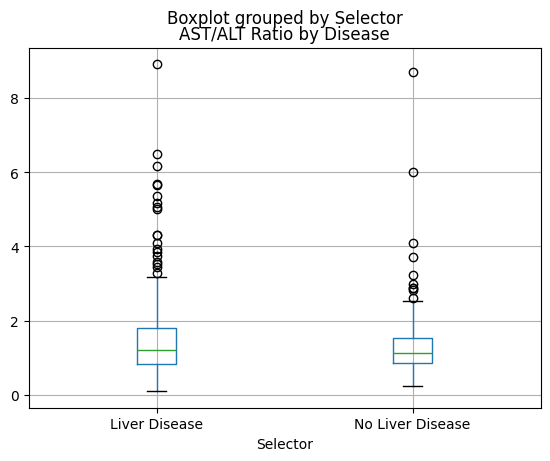

In [34]:
# Create AST/ALT ration (Sgot/Sgpt) and analyze it.


# Create new column
df['AST_ALT_ratio'] = df['Sgot'] / df['Sgpt']

print(df[['Sgot', 'Sgpt', 'AST_ALT_ratio']].head())

#Analyze by disease
result = df.groupby('Selector')['AST_ALT_ratio'].mean().round(2)
print(result)

# Categorize
df['ratio_category'] = df['AST_ALT_ratio'].apply(
    lambda x: 'High (>2)' if x > 2 else ('Moderate (1-2)' if x >= 1 else 'Low (<1)')
)

df.groupby(['ratio_category', 'Selector']).size()
import matplotlib.pyplot as plt

df.boxplot(column='AST_ALT_ratio', by='Selector')
plt.title("AST/ALT Ratio by Disease")
plt.show()



In [35]:
# Build a rule-based prediction and compare with actual results.

# creating the rule.

def predict(row):
    score = 0

    if row['TB'] > 1.2:
        score += 1
    if row['Sgpt'] > 40:
        score += 1
    if row['ALB'] < 3.5:
        score += 1

    return 'Liver Disease' if score >= 2 else 'No Liver Disease'

df['Predicted'] = df.apply(predict, axis=1)

# Compare with actual
comparison = pd.crosstab(df['Selector'], df['Predicted'])
print(comparison)

#Accuracy calculation
accuracy = (df['Selector'] == df['Predicted']).mean() * 100
print("Accuracy:", round(accuracy, 2), "%")



Predicted         Liver Disease  No Liver Disease
Selector                                         
Liver Disease               238               178
No Liver Disease             34               133
Accuracy: 63.64 %


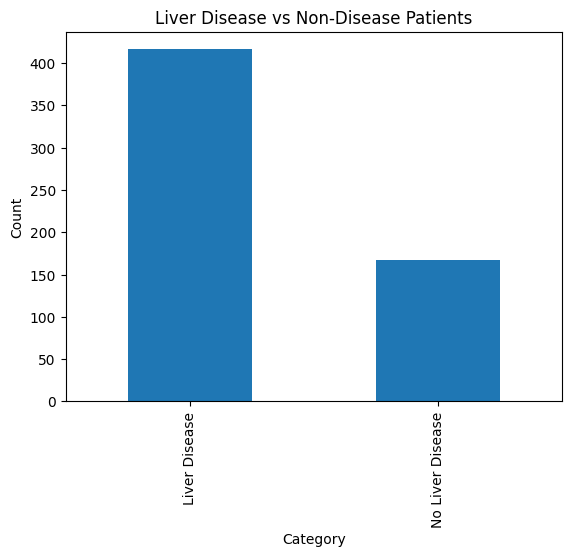

In [37]:
# Visualize data using charts (bar chart,histogram,boxplot)

import matplotlib.pyplot as plt

# Bar chart

df['Selector'].value_counts().plot(kind='bar')

plt.title("Liver Disease vs Non-Disease Patients")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()



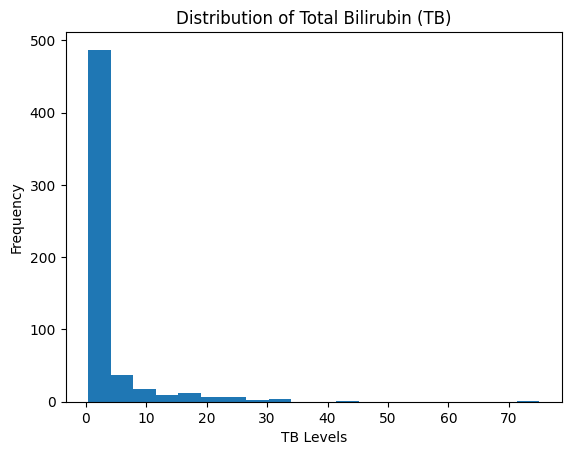

In [38]:
# Histogram

df['TB'].plot(kind='hist', bins=20)

plt.title("Distribution of Total Bilirubin (TB)")
plt.xlabel("TB Levels")
plt.ylabel("Frequency")

plt.show()

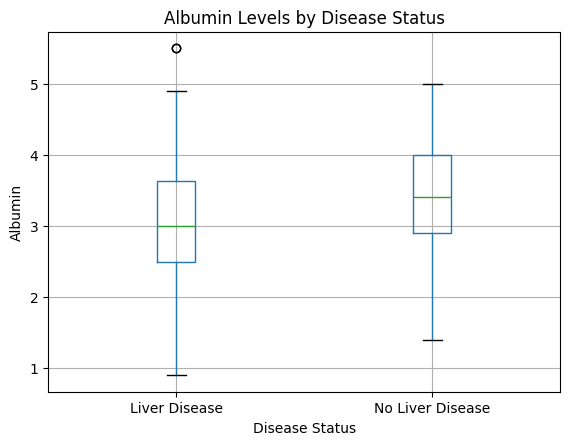

In [41]:
# Boxplot
df.boxplot(column='ALB', by='Selector')

plt.title("Albumin Levels by Disease Status")
plt.suptitle("")  # removes extra title
plt.xlabel("Disease Status")
plt.ylabel("Albumin")

plt.show()

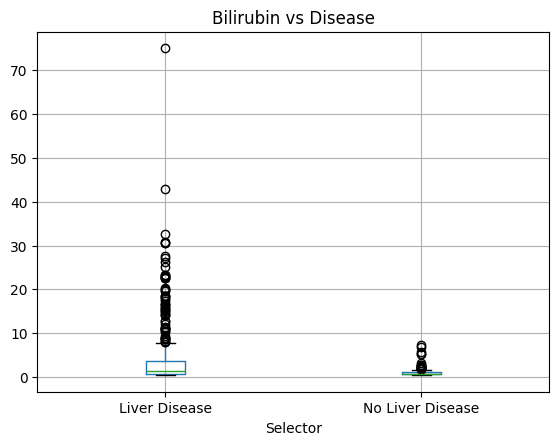

In [40]:
df.boxplot(column='TB', by='Selector')
plt.title("Bilirubin vs Disease")
plt.suptitle("")
plt.show()

In [46]:
import os
print(os.listdir())

['.config', 'liver_patient_analysis', 'liver_patient_dataset.csv', 'sample_data']


In [44]:
df.to_csv("liver_patient_analysis",index=False)

In [48]:
from google.colab import files
files.download("liver_patient_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>